In [1]:
! pip install imbalanced-learn
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler    
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv('C:/Users/mm640/OneDrive/Desktop/data science course/test EDA/datasets/Churn_Modelling.csv')

In [3]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [5]:
df['churn'] = df['Exited'].map({1: 'active', 0: 'churn'})

df['churn'] = np.where(df['Exited'] == 1, 'active', 'churn')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
 14  churn            10000 non-null  object 
dtypes: float64(2), int64(9), object(4)
memory usage: 1.1+ MB


In [7]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,churn
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,active
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,churn
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,active
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,churn
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,churn


In [8]:
new_df=df[['Geography','Gender','churn']]

UNIVARIANT ANALYSIS

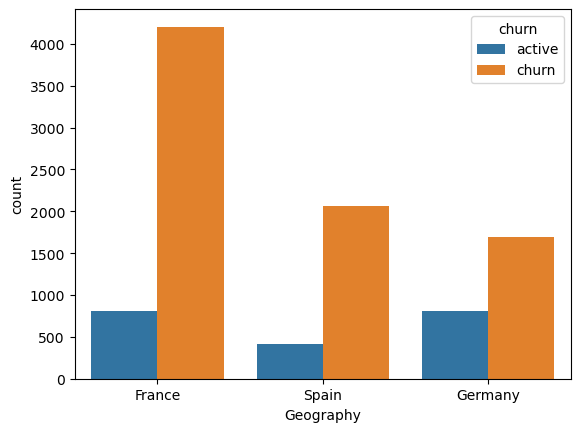

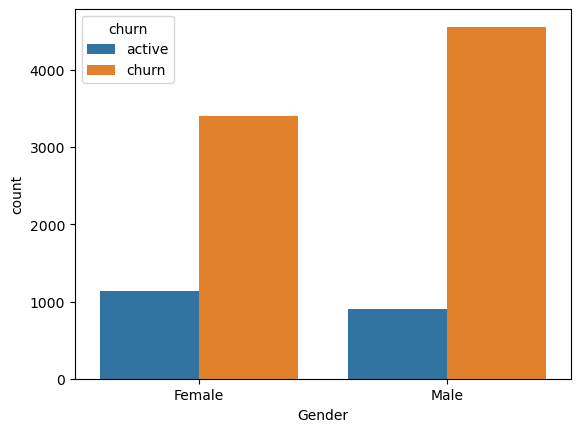

In [9]:
for i ,predictor in enumerate(new_df.drop(columns= ['churn']).columns):
    plt.figure()
    sns.countplot(x=predictor,data=new_df,hue='churn')
    

In [10]:
new_df.Geography.value_counts() 

Geography
France     5014
Germany    2509
Spain      2477
Name: count, dtype: int64

BIvariate analysis

<Axes: xlabel='Gender', ylabel='Count'>

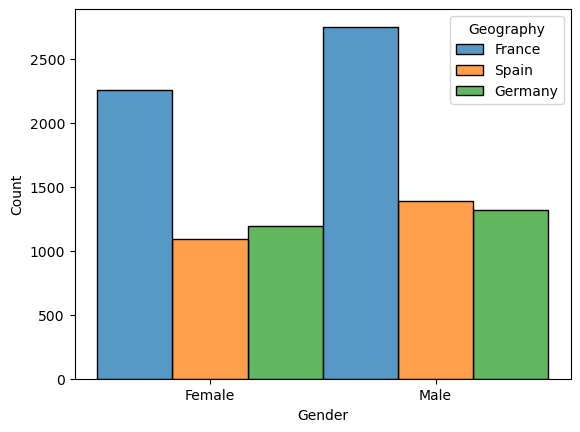

In [11]:
sns.histplot(x='Gender',data=new_df,hue='Geography',multiple='dodge')

Numerical analysis

In [12]:
df.select_dtypes(include=['number']).head()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,619,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,608,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,502,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,699,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,850,43,2,125510.82,1,1,1,79084.10,0


Text(0, 0.5, 'Correlation Coefficient')

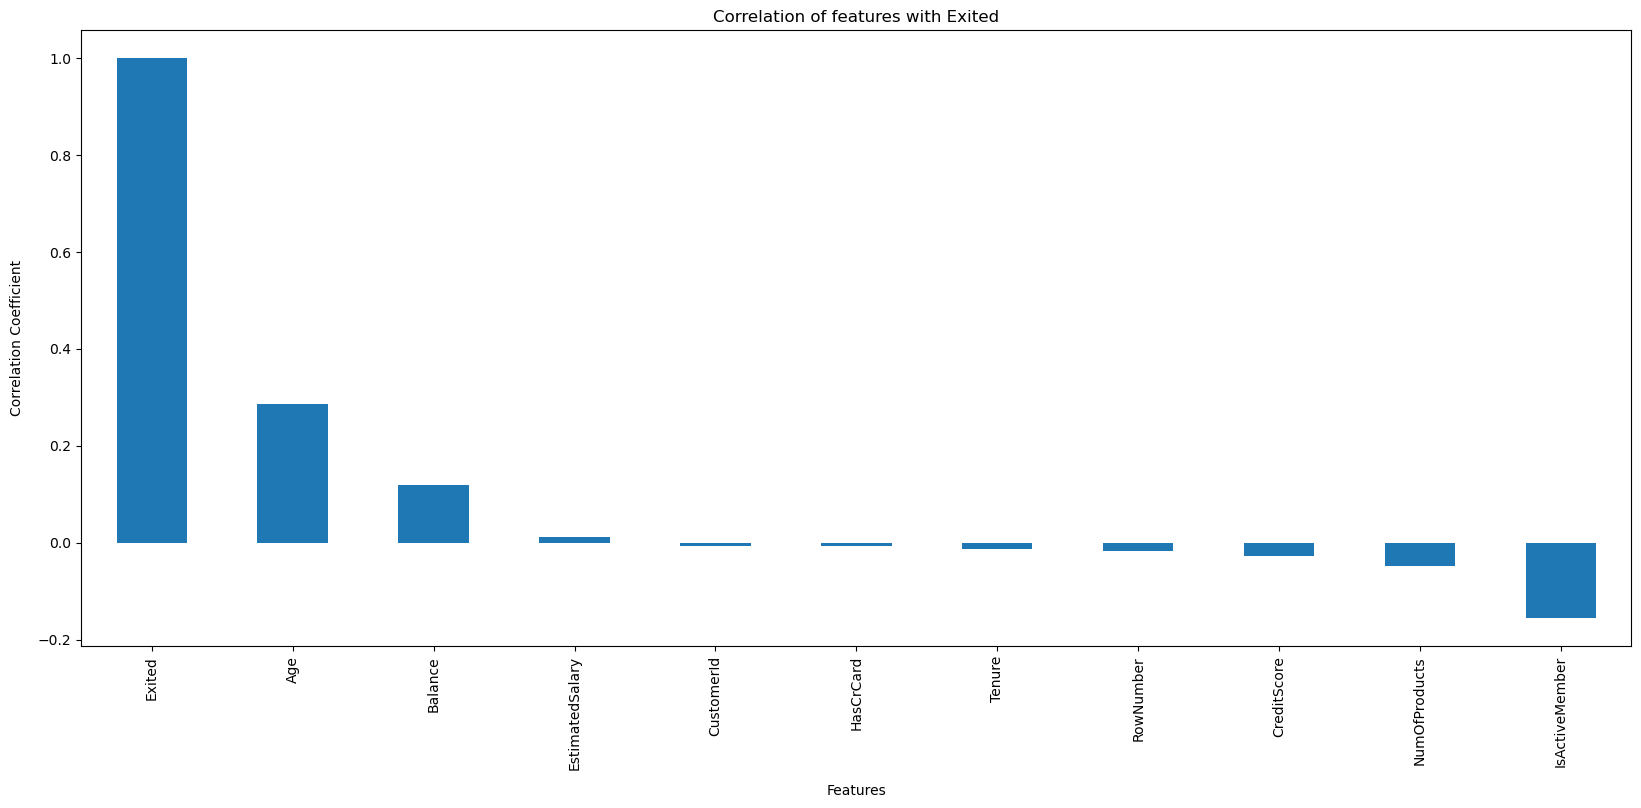

In [13]:
plt.figure(figsize=(20,8))
df.corr(numeric_only = True )['Exited'].sort_values(ascending=False).plot(kind='bar')
plt.title('Correlation of features with Exited')
plt.xlabel('Features', labelpad=10)
plt.ylabel('Correlation Coefficient', labelpad=10)

Text(0.5, 1.0, 'Correlation Heatmap for Churn Modelling')

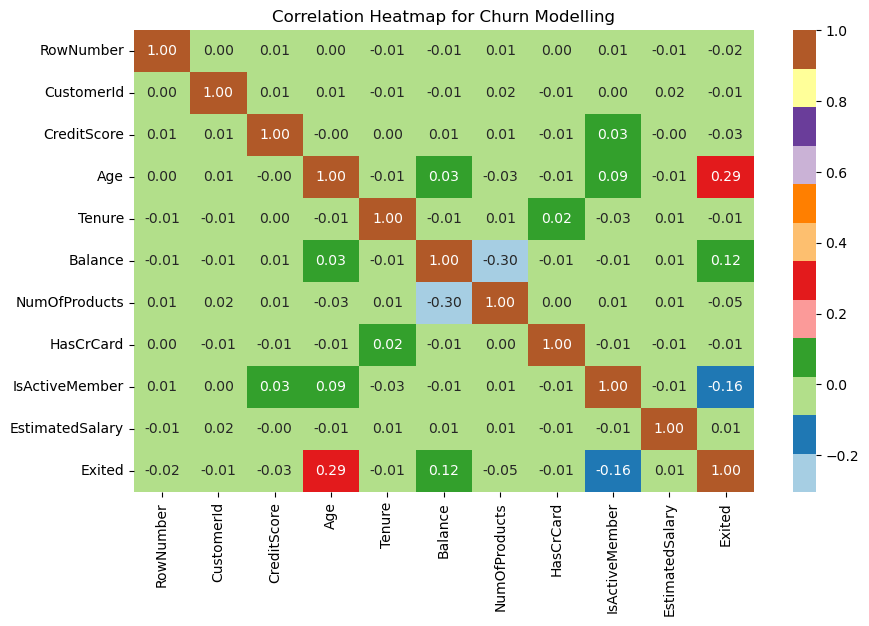

In [14]:
plt.figure(figsize=(10, 6))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f', cmap='Paired',annot_kws={"size": 10})

plt.title('Correlation Heatmap for Churn Modelling')

In [15]:
df.Age.min(), df.Age.max()

(18, 92)

Feature Bin

In [16]:
labels=['0-20','21-40','41-60','Above 60']
bins=[0,21,41,61,100]
df['Age_bin']=pd.cut(df.Age,bins,labels=labels, include_lowest=True, right = False)

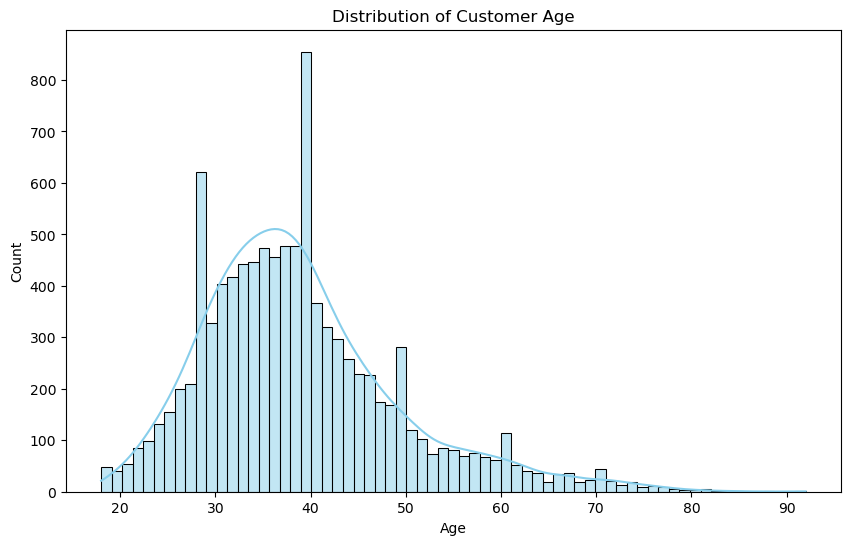

In [17]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], kde=True, color='skyblue')
plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

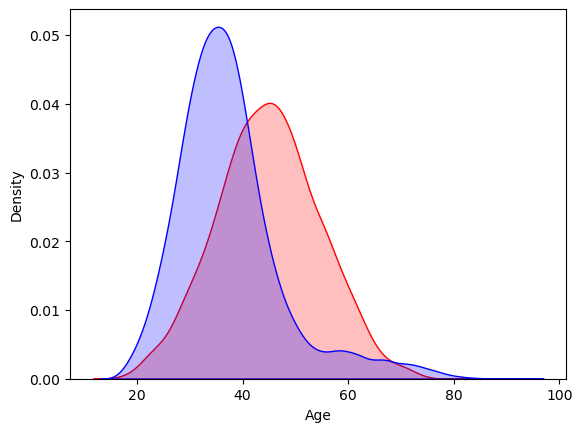

In [18]:
Tot=sns.kdeplot(df.Age[(df['Exited']==1)],color='red',fill=True)
Tot=sns.kdeplot(df.Age[(df['Exited']==0)],color='blue',fill=True)


remove the unneeded columns 



In [19]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,churn,Age_bin
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,active,41-60
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,churn,41-60
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,active,41-60
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,churn,21-40
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,churn,41-60


In [20]:
df.drop(columns=['RowNumber','CustomerId','Surname'], inplace=True)

In [21]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,churn,Age_bin
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,active,41-60
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,churn,41-60
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,active,41-60
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,churn,21-40
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,churn,41-60


Feature Encoding


In [22]:
df_dummies = pd.get_dummies(df,columns=['Geography' , 'Gender'],dtype=int)
df_dummies.head()


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,churn,Age_bin,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,active,41-60,1,0,0,1,0
1,608,41,1,83807.86,1,0,1,112542.58,0,churn,41-60,0,0,1,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,active,41-60,1,0,0,1,0
3,699,39,1,0.00,2,0,0,93826.63,0,churn,21-40,1,0,0,1,0
4,850,43,2,125510.82,1,1,1,79084.10,0,churn,41-60,0,0,1,1,0


train_test_split


In [23]:


y = df_dummies['Exited']

x = df_dummies.drop(columns=[
    'Exited', 'RowNumber', 'CustomerId', 'Surname', 'churn', 'Age_bin'
], errors='ignore')




xtrain, xtest, ytrain, ytest = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

feature scaling 

In [24]:
scaler = StandardScaler()
xtrain_scaled = scaler.fit_transform(xtrain)   
xtest_scaled = scaler.transform(xtest)         
print('After Scaling:')
print(xtrain_scaled[0:2, 0:10])
print('Scaling done')

After Scaling:
[[ 1.058568    1.71508648  0.68472287 -1.22605881 -0.91025649  0.64104192
  -1.030206    1.04208392  1.00175153 -0.57831252]
 [ 0.91362605 -0.65993547 -0.6962018   0.41328769 -0.91025649  0.64104192
  -1.030206   -0.62355635 -0.99825153  1.72916886]]
Scaling done


 Model Selection & Training

In [25]:

from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression


model = LogisticRegression(max_iter=1000)
model.fit(xtrain, ytrain)

rf = RandomForestClassifier(n_estimators=500, max_depth=20   )
rf.fit(xtrain, ytrain)

gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(xtrain, ytrain)

print('Training finished ')


c:\Users\mm640\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Training finished 


In [26]:
smote = SMOTE(random_state=42)
x_train_res, y_train_res = smote.fit_resample(xtrain_scaled, ytrain)

model.fit(x_train_res, y_train_res)
rf.fit(x_train_res, y_train_res)
gb.fit(x_train_res, y_train_res)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

Compare models 

              Model  Accuracy  F1 Score  ROC-AUC
Logistic Regression    0.7185    0.5022   0.7767
      Random Forest    0.8390    0.6044   0.8484
  Gradient Boosting    0.8455    0.6335   0.8634


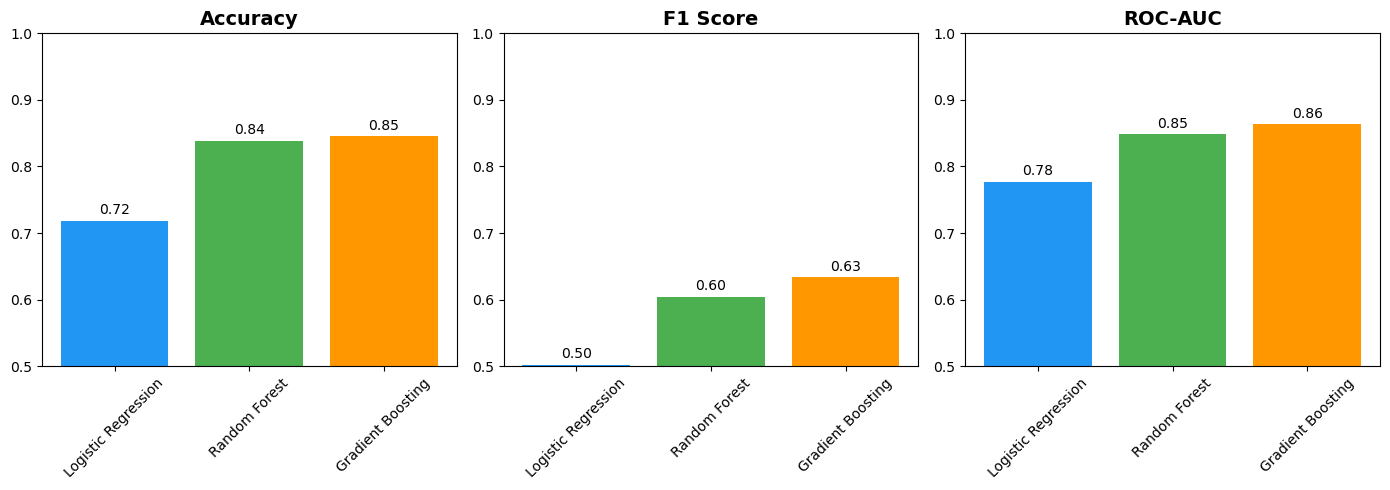

In [27]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score



models = {
    'Logistic Regression': model,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

results = []
for name, m in models.items():
    y_pred = m.predict(xtest_scaled)
    y_prob = m.predict_proba(xtest_scaled)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': round(accuracy_score(ytest, y_pred), 4),
        'F1 Score': round(f1_score(ytest, y_pred), 4),
        'ROC-AUC': round(roc_auc_score(ytest, y_prob), 4)
    })

# Comparison table
df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

metrics = ['Accuracy', 'F1 Score', 'ROC-AUC']
colors = ['#2196F3', '#4CAF50', '#FF9800']

for i, metric in enumerate(metrics):
    bars = axes[i].bar(df_results['Model'], df_results[metric], color=colors)
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylim(0.5, 1.0)
    axes[i].tick_params(axis='x', rotation=45)
    for bar in bars:
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{bar.get_height():.2f}', ha='center', fontsize=10)

plt.tight_layout()
plt.show()




In [28]:
import gradio as gr


#Accuracy cache
_acc_cache = {}
def get_accuracy(selected_model):
    if selected_model not in _acc_cache:
        m = {'Logistic Regression': model,
             'Random Forest': rf,
             'Gradient Boosting': gb}[selected_model]
        y_pred = m.predict(xtest_scaled)
        _acc_cache[selected_model] = round(accuracy_score(ytest, y_pred), 4)
    return _acc_cache[selected_model]

# Predict function 
def predict_churn(credit_score, geography, gender, age, tenure,
                  balance, num_products, has_cr_card, is_active,
                  salary, selected_model):

    row = {
        'CreditScore':       credit_score,
        'Age':               age,
        'Tenure':            tenure,
        'Balance':           balance,
        'NumOfProducts':     num_products,
        'HasCrCard':         has_cr_card,
        'IsActiveMember':    is_active,
        'EstimatedSalary':   salary,
        'Geography_France':  int(geography == 'France'),
        'Geography_Germany': int(geography == 'Germany'),
        'Geography_Spain':   int(geography == 'Spain'),
        'Gender_Female':     int(gender == 'Female'),
        'Gender_Male':       int(gender == 'Male'),
    }

    input_df     = pd.DataFrame([row])[list(x.columns)]
    input_scaled = scaler.transform(input_df)

    m = {'Logistic Regression': model,
         'Random Forest': rf,
         'Gradient Boosting': gb}[selected_model]

    prediction  = m.predict(input_scaled)[0]
    probability = round(float(m.predict_proba(input_scaled)[0][1]), 4)
    accuracy    = get_accuracy(selected_model)
    label       = " Will Churn" if prediction == 1 else " Will Stay"

    return label, probability, accuracy


app = gr.Interface(
    fn=predict_churn,
    inputs=[
        gr.Number(label="Credit Score",       value=650),
        gr.Dropdown(["France", "Germany", "Spain"], label="Geography", value="France"),
        gr.Dropdown(["Male", "Female"],        label="Gender",        value="Male"),
        gr.Number(label="Age",                 value=35),
        gr.Number(label="Tenure",              value=5),
        gr.Number(label="Balance",             value=50000),
        gr.Number(label="Number of Products",  value=1),
        gr.Radio([1, 0], label="Has Credit Card",  value=1),
        gr.Radio([1, 0], label="Is Active Member", value=1),
        gr.Number(label="Estimated Salary",    value=100000),
        gr.Dropdown(
            ["Logistic Regression", "Random Forest", "Gradient Boosting"],
            label="Select Model", value="Gradient Boosting"
        ),
    ],
    outputs=[
        gr.Textbox(label="Prediction Result"),
        gr.Number(label="Churn Probability"),
        gr.Number(label="Model Accuracy"),
    ],
    title="Bank Customer Churn Prediction",
    description="Enter customer information to predict whether the customer will leave the bank or stay.",
)

app.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.
